# Foot / Shoe Axis Debugger

This notebook answers one very specific question:

```text
What direction do the SUPR foot axes point, what direction do the shoe axes point,
and what does our transformation matrix actually do to those directions?
```

The important rule: do not trust the camera/viewer. Trust the file coordinates and the arrows drawn from those coordinates.

In [41]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "5")

from pathlib import Path
import sys
import json

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

FOOTSHELL_ROOT = Path("/data/abelde/projects/active/Shell_Gaussian/FootShellGaussian")
PROJECT_ROOT = FOOTSHELL_ROOT.parent
if str(FOOTSHELL_ROOT) not in sys.path:
    sys.path.insert(0, str(FOOTSHELL_ROOT))

import importlib
import foot_prior as _foot_prior
import foot_prior.foot_alignment as _foot_alignment
importlib.reload(_foot_alignment)
importlib.reload(_foot_prior)

from foot_prior import (
    FootAlignmentConfig,
    MeshData,
    build_alignment_from_meshes,
    detect_shoe_opening_boundary,
    get_single_boundary_loop,
    load_triangle_mesh,
    mesh_bounds,
    principal_yaw_degrees,
    transform_points,
)
from foot_prior.foot_alignment import make_supr_to_shoe_axis_remap

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())


torch: 1.13.1 cuda: True


## 1. Paths

These are the exact assets used in the current debugging setup.

In [42]:
SHOE_NAME = "Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids"
DATASET_SCENE = Path("/data/abelde/datasets/processed/gshell_shoes") / SHOE_NAME
SUPR_FOOT_NPY = PROJECT_ROOT / "baselines" / "SUPR" / "data" / "supr_male_right_foot.npy"
SUPR_FOOT_OBJ = PROJECT_ROOT / "baselines" / "SUPR" / "output" / "debug_playground" / "supr_male_right_foot_neutral.obj"
SHELL_MESH_PATH = PROJECT_ROOT / "baselines" / "GShell" / "output" / f"{SHOE_NAME}_sole_debug" / "mesh" / "mesh.obj"
WATERTIGHT_MESH_PATH = PROJECT_ROOT / "baselines" / "GShell" / "output" / f"{SHOE_NAME}_sole_debug" / "mesh_watertight" / "mesh.obj"
FOOT_SDF_PATH = FOOTSHELL_ROOT / "data" / "foot_prior" / "supr_male_right_foot_sdf.npz"
OUT_DIR = FOOTSHELL_ROOT / "output" / "axis_debug" / SHOE_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

for label, path in [
    ("dataset scene", DATASET_SCENE),
    ("SUPR foot npy", SUPR_FOOT_NPY),
    ("SUPR foot obj", SUPR_FOOT_OBJ),
    ("shell mesh", SHELL_MESH_PATH),
    ("watertight mesh", WATERTIGHT_MESH_PATH),
    ("foot SDF", FOOT_SDF_PATH),
]:
    print(f"{label:16s}: {path} | exists={path.exists()}")


dataset scene   : /data/abelde/datasets/processed/gshell_shoes/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids | exists=True
SUPR foot npy   : /data/abelde/projects/active/Shell_Gaussian/baselines/SUPR/data/supr_male_right_foot.npy | exists=True
SUPR foot obj   : /data/abelde/projects/active/Shell_Gaussian/baselines/SUPR/output/debug_playground/supr_male_right_foot_neutral.obj | exists=True
shell mesh      : /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_sole_debug/mesh/mesh.obj | exists=True
watertight mesh : /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_sole_debug/mesh_watertight/mesh.obj | exists=True
foot SDF        : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/data/foot_prior/supr_male_right_foot_sdf.npz | exists=True


## 2. Load Data

`supr_male_right_foot.npy` is a model dictionary. The neutral vertices are in `v_template`. The OBJ is the same neutral foot exported as a mesh.

In [43]:
supr_model = np.load(SUPR_FOOT_NPY, allow_pickle=True).item()
foot_template = np.asarray(supr_model["v_template"], dtype=np.float32)
foot_mesh = load_triangle_mesh(SUPR_FOOT_OBJ)
shell_mesh = load_triangle_mesh(SHELL_MESH_PATH)
watertight_mesh = load_triangle_mesh(WATERTIGHT_MESH_PATH)

print("SUPR npy keys:", sorted(supr_model.keys()))
print("v_template:", foot_template.shape, foot_template.dtype)
print("foot OBJ:", foot_mesh.vertices.shape, foot_mesh.faces.shape)
print("shell mesh:", shell_mesh.vertices.shape, shell_mesh.faces.shape)
print("watertight mesh:", watertight_mesh.vertices.shape, watertight_mesh.faces.shape)
print("max |OBJ - v_template|:", float(np.max(np.abs(foot_mesh.vertices - foot_template))))


SUPR npy keys: ['J', 'J_regressor', 'f', 'kintree_table', 'posedirs', 'shapedirs', 'v_template', 'weights']
v_template: (266, 3) float32
foot OBJ: (266, 3) (515, 3)
shell mesh: (2005, 3) (3052, 3)
watertight mesh: (1616, 3) (3228, 3)
max |OBJ - v_template|: 7.450580596923828e-09


## 3. Plot Helpers

The arrows and coordinate lines are the main thing. Mesh shading can lie to your eyes; red, green, and blue lines show the actual file-coordinate directions. The plots below include one clean coordinate view and one turntable grid.

In [44]:
def unit(vector):
    vector = np.asarray(vector, dtype=np.float32)
    norm = np.linalg.norm(vector)
    if norm < 1e-8:
        return vector
    return vector / norm


def centered(vertices):
    vertices = np.asarray(vertices, dtype=np.float32)
    return vertices - vertices.mean(axis=0, keepdims=True)


def fit_plane_normal(points, prefer_direction=None):
    points = np.asarray(points, dtype=np.float32)
    local = points - points.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(local, full_matrices=False)
    normal = unit(vh[-1])
    if prefer_direction is not None and float(np.dot(normal, prefer_direction)) < 0.0:
        normal = -normal
    return normal


def print_bounds(name, vertices):
    mn, mx, size, center = mesh_bounds(vertices)
    print(name)
    print("  min   :", mn)
    print("  max   :", mx)
    print("  size  :", size)
    print("  center:", center)


def sample_faces(mesh, max_faces=2500):
    if mesh.faces.shape[0] <= max_faces:
        return mesh.faces
    indices = np.linspace(0, mesh.faces.shape[0] - 1, max_faces).astype(np.int64)
    return mesh.faces[indices]


def set_axes_equal(ax, vertices_list):
    all_vertices = np.concatenate([np.asarray(vertices).reshape(-1, 3) for vertices in vertices_list if np.asarray(vertices).size], axis=0)
    bounds_min = all_vertices.min(axis=0)
    bounds_max = all_vertices.max(axis=0)
    center_point = (bounds_min + bounds_max) * 0.5
    radius = max((bounds_max - bounds_min).max() * 0.58, 1e-6)
    ax.set_xlim(center_point[0] - radius, center_point[0] + radius)
    ax.set_ylim(center_point[1] - radius, center_point[1] + radius)
    ax.set_zlim(center_point[2] - radius, center_point[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
        ax.set_proj_type("ortho")
    except Exception:
        pass


def add_mesh(ax, mesh, color="#bdbdbd", alpha=0.45, max_faces=2500, linewidth=0.08):
    faces = sample_faces(mesh, max_faces=max_faces)
    poly = Poly3DCollection(mesh.vertices[faces], alpha=alpha, linewidths=linewidth)
    poly.set_facecolor(color)
    poly.set_edgecolor("#222222")
    ax.add_collection3d(poly)


def add_arrow(ax, origin, direction, label, color, length=0.06, linewidth=2.5):
    origin = np.asarray(origin, dtype=np.float32)
    direction = unit(direction) * length
    ax.quiver(
        origin[0], origin[1], origin[2],
        direction[0], direction[1], direction[2],
        color=color,
        linewidth=linewidth,
        arrow_length_ratio=0.18,
        normalize=False,
    )
    if label:
        tip = origin + direction * 1.08
        ax.text(tip[0], tip[1], tip[2], label, color=color, fontsize=10)


def add_axis_line(ax, origin, direction, label, color, length=0.2, labels=True, linewidth=1.7):
    origin = np.asarray(origin, dtype=np.float32)
    direction = unit(direction)
    start = origin - direction * length
    end = origin + direction * length
    ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], color=color, linewidth=linewidth)
    if labels:
        label_point = origin + direction * length * 0.82
        ax.text(label_point[0], label_point[1], label_point[2], label, color=color, fontsize=9)


def add_coordinate_lines(ax, origin, length=0.2, labels=True, names=("+X", "+Y", "+Z")):
    add_axis_line(ax, origin, [1, 0, 0], names[0], "#ff5a6e", length=length, labels=labels)
    add_axis_line(ax, origin, [0, 1, 0], names[1], "#31d17c", length=length, labels=labels)
    add_axis_line(ax, origin, [0, 0, 1], names[2], "#8b8cff", length=length, labels=labels)


def add_reference_rings(ax, origin, radius, color="#d7d7ff", linewidth=0.7, alpha=0.55):
    origin = np.asarray(origin, dtype=np.float32)
    angles = np.linspace(0.0, 2.0 * np.pi, 160)
    circles = [
        np.stack([np.cos(angles), np.sin(angles), np.zeros_like(angles)], axis=1),
        np.stack([np.cos(angles), np.zeros_like(angles), np.sin(angles)], axis=1),
        np.stack([np.zeros_like(angles), np.cos(angles), np.sin(angles)], axis=1),
    ]
    for circle in circles:
        points = origin[None, :] + radius * circle
        ax.plot(points[:, 0], points[:, 1], points[:, 2], color=color, linewidth=linewidth, alpha=alpha)


def add_world_axes(ax, origin, length=0.05, labels=True):
    add_arrow(ax, origin, [1, 0, 0], "+X" if labels else "", "#d73027", length)
    add_arrow(ax, origin, [0, 1, 0], "+Y" if labels else "", "#1a9850", length)
    add_arrow(ax, origin, [0, 0, 1], "+Z" if labels else "", "#2166ac", length)


def make_display_mesh(mesh, axis_order=None):
    if axis_order is None:
        return mesh
    return MeshData(np.asarray(mesh.vertices)[:, axis_order].astype(np.float32), mesh.faces)


def display_points(points, axis_order=None):
    points = np.asarray(points, dtype=np.float32)
    if axis_order is None:
        return points
    return points[:, axis_order]


def display_vector(vector, axis_order=None):
    vector = np.asarray(vector, dtype=np.float32)
    if axis_order is None:
        return vector
    return vector[axis_order]


def style_axis(ax, dark=False):
    ax.set_axis_off()
    if dark:
        ax.set_facecolor("#171a3a")
        ax.figure.patch.set_facecolor("#171a3a")
        try:
            ax.xaxis.set_pane_color((0.08, 0.09, 0.18, 1.0))
            ax.yaxis.set_pane_color((0.08, 0.09, 0.18, 1.0))
            ax.zaxis.set_pane_color((0.08, 0.09, 0.18, 1.0))
        except Exception:
            pass


def plot_coordinate_view(draw_scene, bounds_vertices, title, output_path, elev=20, azim=-55, dark=True):
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")
    draw_scene(ax, show_labels=True)
    set_axes_equal(ax, bounds_vertices)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=15, color="white" if dark else "black")
    style_axis(ax, dark=dark)
    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches="tight", pad_inches=0.05, facecolor=fig.get_facecolor())
    plt.show()


def plot_turntable(draw_scene, bounds_vertices, title, output_path, elev=12, azims=(-120, -60, 0, 60, 120, 180)):
    fig = plt.figure(figsize=(18, 8))
    for subplot_index, azim in enumerate(azims, start=1):
        ax = fig.add_subplot(2, 3, subplot_index, projection="3d")
        draw_scene(ax, show_labels=(subplot_index == 1))
        set_axes_equal(ax, bounds_vertices)
        ax.view_init(elev=elev, azim=azim)
        ax.set_title(f"azim {azim} deg", fontsize=11)
        ax.set_axis_off()
    fig.suptitle(title, fontsize=16)
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.90, wspace=0.02, hspace=0.05)
    plt.savefig(output_path, dpi=180, bbox_inches="tight", pad_inches=0.05)
    plt.show()


## 4. Raw SUPR Foot Axes

This answers: if the foot is centered at `(0, 0, 0)`, which coordinate direction points to the toes, sole, and ankle cut?

raw SUPR foot
  min   : [-0.16143256 -1.3569797  -0.11568644]
  max   : [-0.05844138 -1.2518517   0.15629017]
  size  : [0.10299119 0.10512805 0.27197662]
  center: [-0.10993697 -1.3044157   0.02030187]
raw SUPR ankle boundary
  min   : [-0.12789522 -1.2565387  -0.09917974]
  max   : [-0.06272307 -1.2518517  -0.00369378]
  size  : [0.06517215 0.00468707 0.09548596]
  center: [-0.09530915 -1.2541952  -0.05143676]
ankle cut normal from fitted boundary plane: [0.01729961 0.99892026 0.04311712]
dot(normal, +Y): 0.9989202618598938

Conclusion from raw data:
  toes direction      = +Z
  heel direction      = -Z
  ankle/missing leg   = +Y
  sole direction      = -Y
  width direction     = X

Coordinate colors in the raw-foot visual:
  red   = display X = raw SUPR +Z = toes
  green = display Y = raw SUPR +X = width
  blue  = display Z = raw SUPR +Y = ankle/up
  purple arrow = ankle cut normal / missing-leg direction


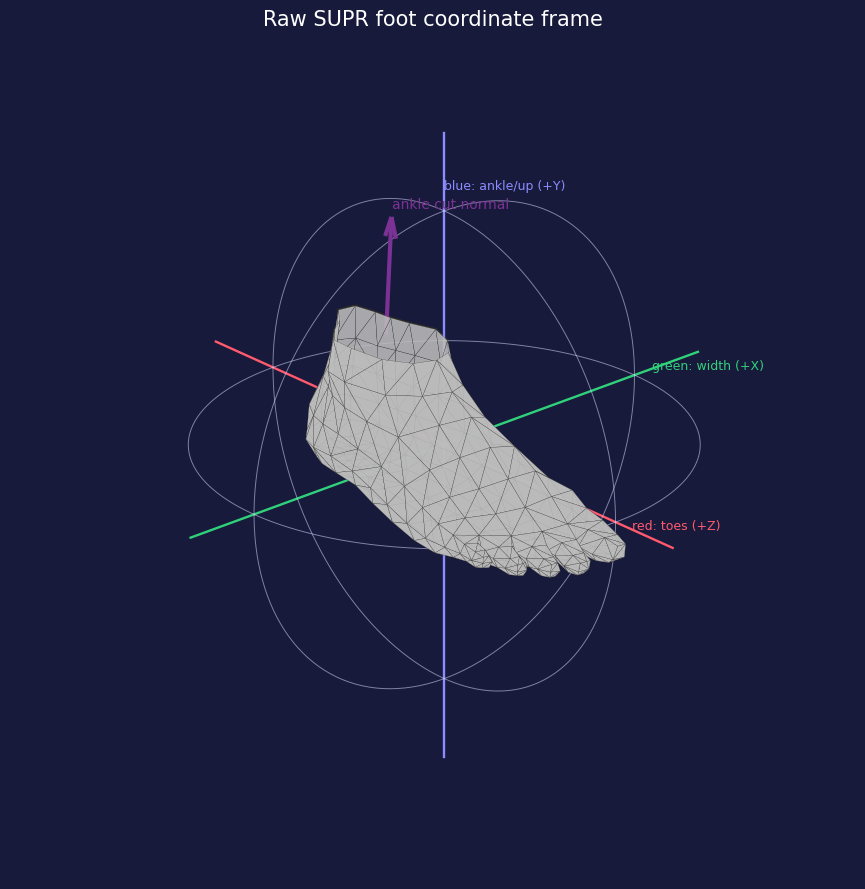

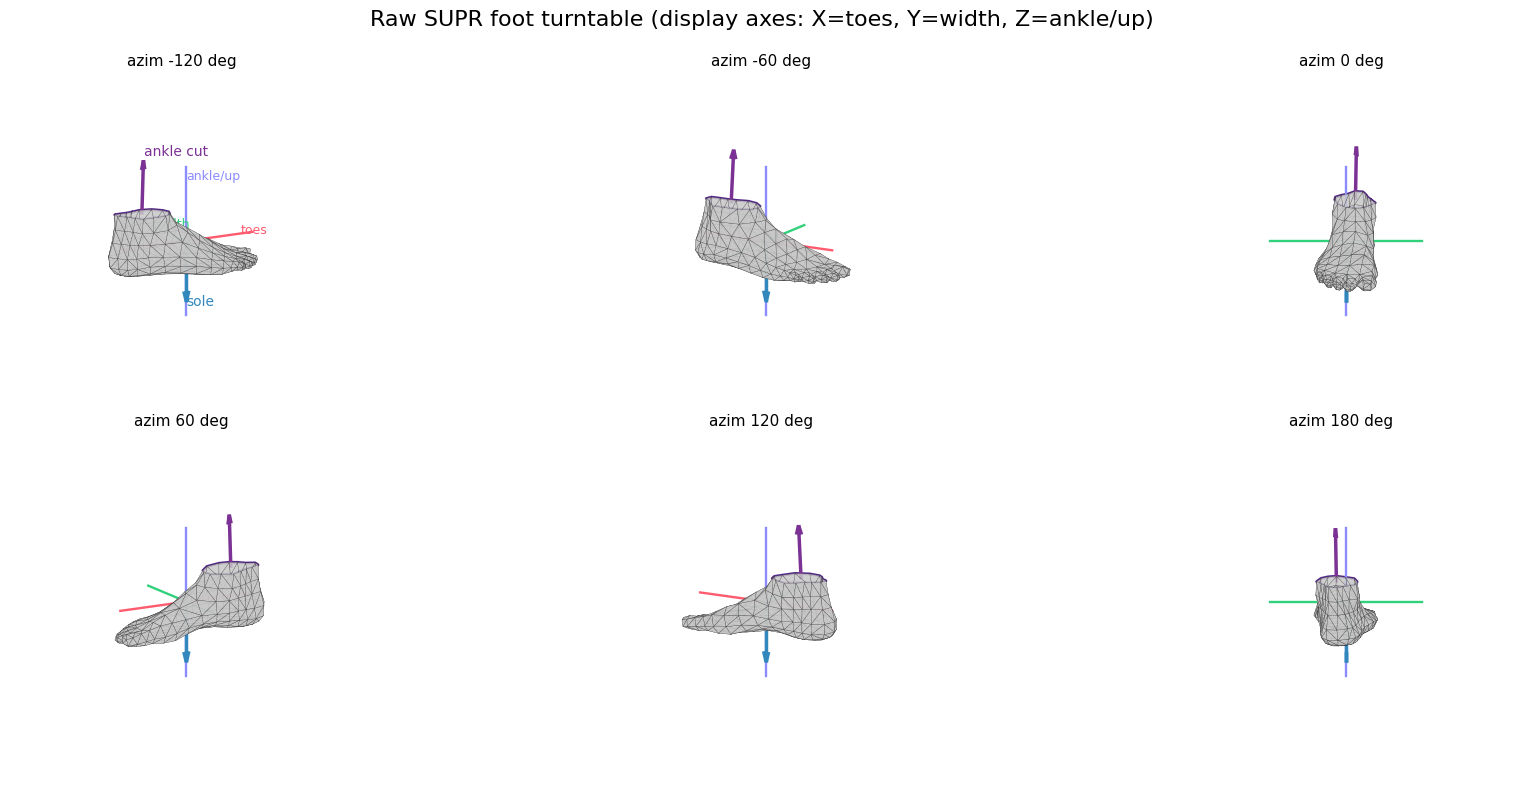

In [45]:
foot_centered = MeshData(centered(foot_mesh.vertices), foot_mesh.faces)
loop_indices = get_single_boundary_loop(foot_mesh)
loop_raw = foot_mesh.vertices[loop_indices]
loop_centered = foot_centered.vertices[loop_indices]
ankle_normal_raw = fit_plane_normal(loop_raw, prefer_direction=np.asarray([0.0, 1.0, 0.0], dtype=np.float32))

print_bounds("raw SUPR foot", foot_mesh.vertices)
print_bounds("raw SUPR ankle boundary", loop_raw)
print("ankle cut normal from fitted boundary plane:", ankle_normal_raw)
print("dot(normal, +Y):", float(np.dot(ankle_normal_raw, [0, 1, 0])))
print()
print("Conclusion from raw data:")
print("  toes direction      = +Z")
print("  heel direction      = -Z")
print("  ankle/missing leg   = +Y")
print("  sole direction      = -Y")
print("  width direction     = X")
print()
print("Coordinate colors in the raw-foot visual:")
print("  red   = display X = raw SUPR +Z = toes")
print("  green = display Y = raw SUPR +X = width")
print("  blue  = display Z = raw SUPR +Y = ankle/up")
print("  purple arrow = ankle cut normal / missing-leg direction")

# Display remap only: this is not alignment, just a readable anatomical view.
raw_display_order = [2, 0, 1]
foot_display = make_display_mesh(foot_centered, raw_display_order)
loop_display = display_points(loop_centered, raw_display_order)
toe_display = display_vector([0, 0, 1], raw_display_order)
sole_display = display_vector([0, -1, 0], raw_display_order)
ankle_normal_display = display_vector(ankle_normal_raw, raw_display_order)
foot_display_origin = mesh_bounds(foot_display.vertices)[3]
foot_axis_length = float(mesh_bounds(foot_display.vertices)[2].max() * 0.82)


def draw_raw_supr_coordinate(ax, show_labels=True):
    add_mesh(ax, foot_display, color="#bdbdbd", alpha=0.88, max_faces=900, linewidth=0.18)
    ax.plot(
        np.r_[loop_display[:, 0], loop_display[0, 0]],
        np.r_[loop_display[:, 1], loop_display[0, 1]],
        np.r_[loop_display[:, 2], loop_display[0, 2]],
        color="#2b2b2b",
        linewidth=2.0,
    )
    add_coordinate_lines(
        ax,
        foot_display_origin,
        length=foot_axis_length,
        labels=show_labels,
        names=("red: toes (+Z)", "green: width (+X)", "blue: ankle/up (+Y)"),
    )
    add_reference_rings(ax, foot_display_origin, radius=foot_axis_length * 0.75)
    add_arrow(ax, loop_display.mean(axis=0), ankle_normal_display, "ankle cut normal" if show_labels else "", "#7b3294", length=foot_axis_length * 0.38, linewidth=3.0)


def draw_raw_supr_turntable(ax, show_labels=True):
    add_mesh(ax, foot_display, color="#c7c7c7", alpha=0.85, max_faces=900, linewidth=0.18)
    ax.plot(
        np.r_[loop_display[:, 0], loop_display[0, 0]],
        np.r_[loop_display[:, 1], loop_display[0, 1]],
        np.r_[loop_display[:, 2], loop_display[0, 2]],
        color="#542788",
        linewidth=2.0,
    )
    add_coordinate_lines(
        ax,
        foot_display_origin,
        length=foot_axis_length * 0.55,
        labels=show_labels,
        names=("toes", "width", "ankle/up"),
    )
    add_arrow(ax, foot_display_origin, sole_display, "sole" if show_labels else "", "#3288bd", length=foot_axis_length * 0.45)
    add_arrow(ax, loop_display.mean(axis=0), ankle_normal_display, "ankle cut" if show_labels else "", "#7b3294", length=foot_axis_length * 0.40)

plot_coordinate_view(
    draw_raw_supr_coordinate,
    [foot_display.vertices],
    "Raw SUPR foot coordinate frame",
    OUT_DIR / "01_raw_supr_axes_coordinate_view.png",
    elev=24,
    azim=-42,
    dark=True,
)

plot_turntable(
    draw_raw_supr_turntable,
    [foot_display.vertices],
    "Raw SUPR foot turntable (display axes: X=toes, Y=width, Z=ankle/up)",
    OUT_DIR / "01_raw_supr_axes_turntable.png",
    elev=14,
)


## 5. Raw GShell Shoe Axes

This is the shoe mesh by itself, before the SUPR foot is mapped into it. Red, green, and blue show the actual file-coordinate axes for the shoe. For this raw GShell shoe, the important correction is: `Y` is the shoe height/opening-to-sole axis, and `Z` is the shoe width axis. The large missing-sole boundary is also shown so it does not get mistaken for the collar.


raw shell shoe
  min   : [-0.14739399 -0.06755324 -0.06746243]
  max   : [0.14367275 0.07245061 0.05416977]
  size  : [0.29106674 0.14000386 0.1216322 ]
  center: [-0.00186062  0.00244868 -0.00664633]
raw watertight shoe
  min   : [-0.14739399 -0.06755324 -0.06746243]
  max   : [0.14367275 0.07327574 0.05416977]
  size  : [0.29106674 0.140829   0.1216322 ]
  center: [-0.00186062  0.00286125 -0.00664633]

Coordinate colors in the raw-shoe visual:
  red   = shoe +X / length direction
  green = shoe Y axis / height direction
          +Y is the missing sole/base side for this mesh
          -Y is the opening/up side for this mesh
  blue  = shoe +Z / width direction

Largest boundary components in the raw shell:
  component  0: n= 531 center=[-0.02361  0.0606  -0.00851] size=[0.23228 0.02371 0.1111 ] height_pos=0.085 length_ratio=0.798 width_ratio=0.913 -> SOLE-LIKE / missing base
  component  1: n= 165 center=[-0.07399 -0.0377   0.00597] size=[0.09112 0.05535 0.08509] height_pos=0.787 len

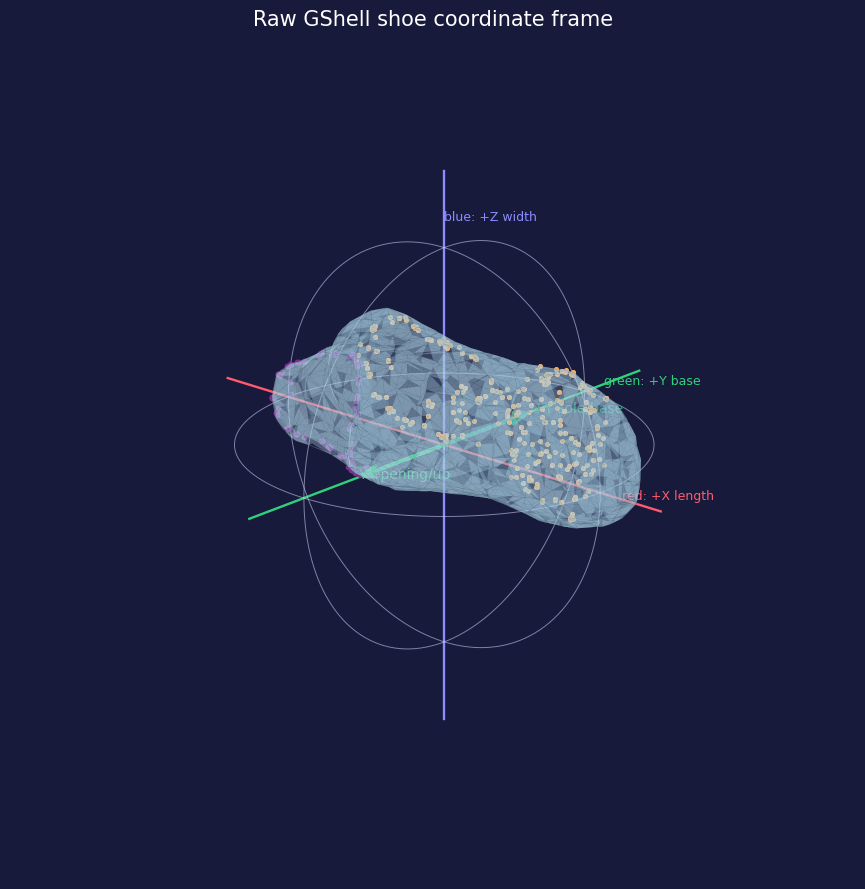

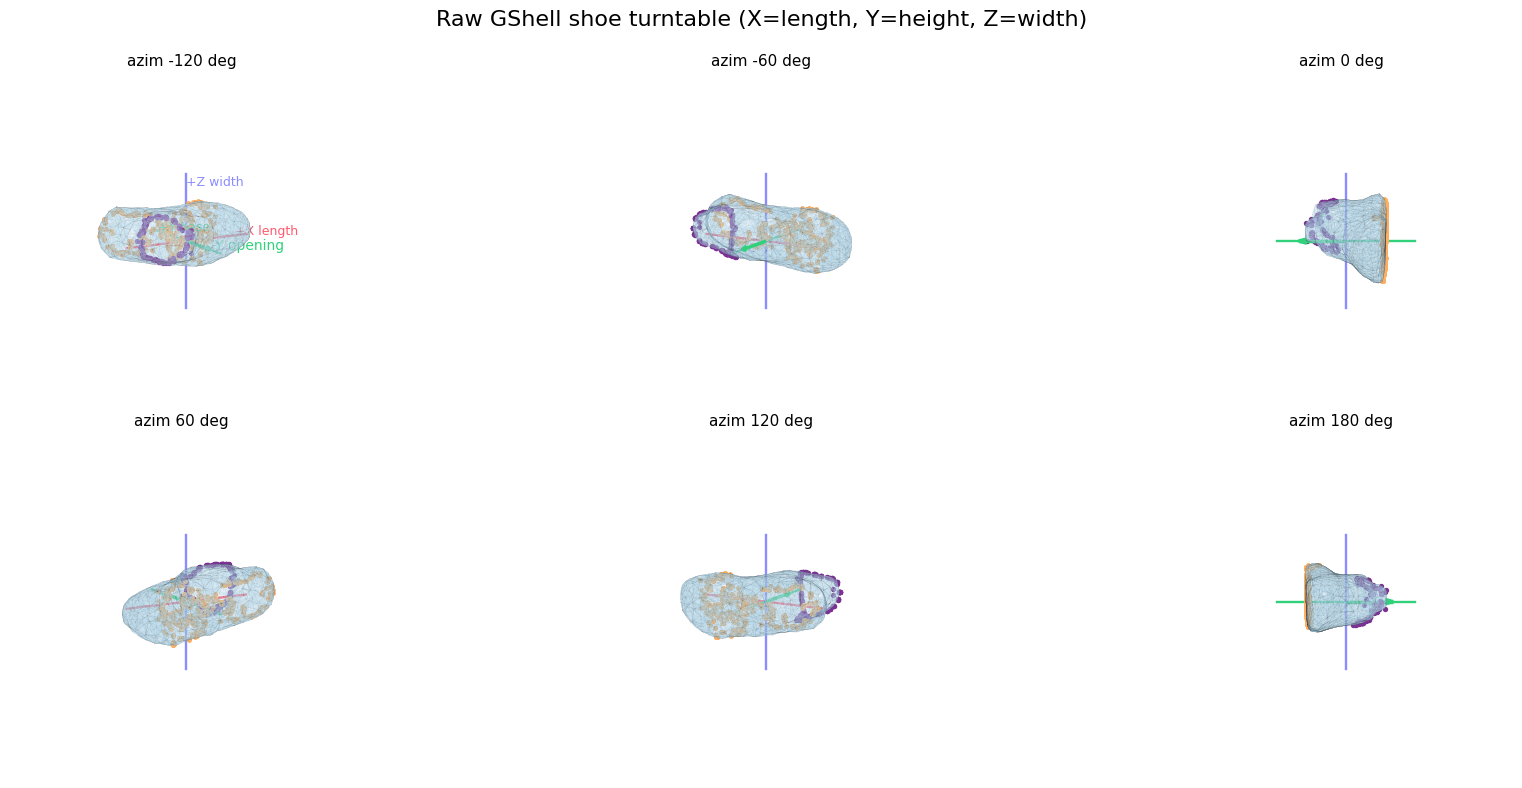

In [46]:
shoe_axis_config = FootAlignmentConfig()
print_bounds("raw shell shoe", shell_mesh.vertices)
print_bounds("raw watertight shoe", watertight_mesh.vertices)
print()
print("Coordinate colors in the raw-shoe visual:")
print("  red   = shoe +X / length direction")
print("  green = shoe Y axis / height direction")
print("          +Y is the missing sole/base side for this mesh")
print("          -Y is the opening/up side for this mesh")
print("  blue  = shoe +Z / width direction")

shoe_center = mesh_bounds(watertight_mesh.vertices)[3]
shoe_axis_length = float(mesh_bounds(watertight_mesh.vertices)[2].max() * 0.70)

components, _edge_components = _foot_alignment.find_boundary_components(shell_mesh)
shoe_signed_up = _foot_alignment.signed_axis_values(
    shell_mesh.vertices,
    shoe_axis_config.shoe_up_axis,
    shoe_axis_config.shoe_up_sign,
)
shoe_signed_up_min = float(shoe_signed_up.min())
shoe_signed_up_extent = max(float(shoe_signed_up.max() - shoe_signed_up_min), 1e-8)
shoe_min, shoe_max, shoe_size, _ = mesh_bounds(shell_mesh.vertices)

shoe_boundary_info = []
for component_index, component in enumerate(components):
    vertices = shell_mesh.vertices[np.asarray(component, dtype=np.int64)]
    bounds_min, bounds_max, size, center = mesh_bounds(vertices)
    length_ratio = float(size[shoe_axis_config.shoe_length_axis] / max(shoe_size[shoe_axis_config.shoe_length_axis], 1e-8))
    width_ratio = float(size[shoe_axis_config.shoe_width_axis] / max(shoe_size[shoe_axis_config.shoe_width_axis], 1e-8))
    up_ratio = float(size[shoe_axis_config.shoe_up_axis] / max(shoe_size[shoe_axis_config.shoe_up_axis], 1e-8))
    signed_center_up = float(_foot_alignment.axis_sign(shoe_axis_config.shoe_up_sign) * center[shoe_axis_config.shoe_up_axis])
    height_position = float((signed_center_up - shoe_signed_up_min) / shoe_signed_up_extent)
    normal = _foot_alignment.fit_plane_normal(vertices)
    sole_like = (
        length_ratio > shoe_axis_config.opening_max_length_ratio
        and height_position < shoe_axis_config.opening_min_height_position
    )
    shoe_boundary_info.append({
        "index": component_index,
        "vertices": np.asarray(component, dtype=np.int64),
        "count": int(len(component)),
        "center": center,
        "size": size,
        "length_ratio": length_ratio,
        "width_ratio": width_ratio,
        "up_ratio": up_ratio,
        "height_position": height_position,
        "normal": normal,
        "sole_like": bool(sole_like),
    })

shoe_boundary_info_by_size = sorted(shoe_boundary_info, key=lambda item: item["count"], reverse=True)
raw_shoe_opening = detect_shoe_opening_boundary(shell_mesh, shoe_axis_config)
sole_like_boundaries = [item for item in shoe_boundary_info if item["sole_like"]]

print()
print("Largest boundary components in the raw shell:")
for item in shoe_boundary_info_by_size[:6]:
    kind = "SOLE-LIKE / missing base" if item["sole_like"] else "possible collar/hole"
    print(
        f"  component {item['index']:2d}: n={item['count']:4d} "
        f"center={np.round(item['center'], 5)} size={np.round(item['size'], 5)} "
        f"height_pos={item['height_position']:.3f} length_ratio={item['length_ratio']:.3f} "
        f"width_ratio={item['width_ratio']:.3f} -> {kind}"
    )

if raw_shoe_opening is not None:
    print()
    print("Selected collar/opening candidate after skipping sole-like boundaries:")
    print("  component:", raw_shoe_opening["index"])
    print("  center   :", raw_shoe_opening["center"])
    print("  size     :", raw_shoe_opening["size"])
    print("  normal   :", raw_shoe_opening["normal"])


def draw_raw_shoe_coordinate(ax, show_labels=True):
    add_mesh(ax, watertight_mesh, color="#bcdff1", alpha=0.34, max_faces=2800, linewidth=0.035)
    add_mesh(ax, shell_mesh, color="#9ecae1", alpha=0.22, max_faces=3500, linewidth=0.030)
    add_coordinate_lines(
        ax,
        shoe_center,
        length=shoe_axis_length,
        labels=show_labels,
        names=("red: +X length", "green: +Y base", "blue: +Z width"),
    )
    add_reference_rings(ax, shoe_center, radius=shoe_axis_length * 0.72)
    add_arrow(ax, shoe_center, [0, -1, 0], "-Y opening/up" if show_labels else "", "#31d17c", length=shoe_axis_length * 0.42, linewidth=3.0)
    add_arrow(ax, shoe_center, [0, 1, 0], "+Y sole/base" if show_labels else "", "#1b9e77", length=shoe_axis_length * 0.42, linewidth=3.0)
    for item in sole_like_boundaries[:1]:
        vertices = shell_mesh.vertices[item["vertices"]]
        ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color="#fdae61", s=7, depthshade=False)
    if raw_shoe_opening is not None:
        vertices = shell_mesh.vertices[np.asarray(raw_shoe_opening["vertices"], dtype=np.int64)]
        ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color="#7b3294", s=9, depthshade=False)


def draw_raw_shoe_turntable(ax, show_labels=True):
    add_mesh(ax, watertight_mesh, color="#bcdff1", alpha=0.34, max_faces=2800, linewidth=0.035)
    add_mesh(ax, shell_mesh, color="#9ecae1", alpha=0.22, max_faces=3500, linewidth=0.030)
    add_coordinate_lines(
        ax,
        shoe_center,
        length=shoe_axis_length * 0.58,
        labels=show_labels,
        names=("+X length", "+Y base", "+Z width"),
    )
    add_arrow(ax, shoe_center, [0, -1, 0], "-Y opening" if show_labels else "", "#31d17c", length=shoe_axis_length * 0.40)
    for item in sole_like_boundaries[:1]:
        vertices = shell_mesh.vertices[item["vertices"]]
        ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color="#fdae61", s=6, depthshade=False)
    if raw_shoe_opening is not None:
        vertices = shell_mesh.vertices[np.asarray(raw_shoe_opening["vertices"], dtype=np.int64)]
        ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color="#7b3294", s=8, depthshade=False)

plot_coordinate_view(
    draw_raw_shoe_coordinate,
    [shell_mesh.vertices, watertight_mesh.vertices],
    "Raw GShell shoe coordinate frame",
    OUT_DIR / "02_raw_shoe_axes_coordinate_view.png",
    elev=20,
    azim=-48,
    dark=True,
)

plot_turntable(
    draw_raw_shoe_turntable,
    [shell_mesh.vertices, watertight_mesh.vertices],
    "Raw GShell shoe turntable (X=length, Y=height, Z=width)",
    OUT_DIR / "02_raw_shoe_axes_turntable.png",
    elev=12,
)


## 6. The Axis Remap Matrix

This is the exact conversion from raw SUPR coordinates into GShell-style shoe coordinates. This is the part we need to verify before discussing alignment.

In [47]:
remap = make_supr_to_shoe_axis_remap(
    shoe_length_axis=0,
    shoe_up_axis=1,
    shoe_width_axis=2,
    shoe_length_sign=1.0,
    shoe_up_sign=-1.0,
    shoe_width_sign=1.0,
)
print("SUPR-to-shoe axis remap matrix:")
print(remap)
print()

basis = {
    "SUPR +X width": np.asarray([1, 0, 0], dtype=np.float32),
    "SUPR +Y ankle/up": np.asarray([0, 1, 0], dtype=np.float32),
    "SUPR +Z toes": np.asarray([0, 0, 1], dtype=np.float32),
    "SUPR -Y sole": np.asarray([0, -1, 0], dtype=np.float32),
}
for label, vector in basis.items():
    mapped = remap @ vector
    print(f"{label:18s} -> shoe {mapped}")

print()
print("Expected mapping for this raw shoe orientation:")
print("  SUPR +Z toes      -> shoe +X")
print("  SUPR +Y ankle/up  -> shoe -Y  (opening/up side)")
print("  SUPR -Y sole      -> shoe +Y  (missing sole/base side)")
print("  SUPR +X width     -> shoe +Z")


SUPR-to-shoe axis remap matrix:
[[ 0.  0.  1.]
 [ 0. -1.  0.]
 [ 1.  0.  0.]]

SUPR +X width      -> shoe [0. 0. 1.]
SUPR +Y ankle/up   -> shoe [ 0. -1.  0.]
SUPR +Z toes       -> shoe [1. 0. 0.]
SUPR -Y sole       -> shoe [0. 1. 0.]

Expected mapping for this raw shoe orientation:
  SUPR +Z toes      -> shoe +X
  SUPR +Y ankle/up  -> shoe -Y  (opening/up side)
  SUPR -Y sole      -> shoe +Y  (missing sole/base side)
  SUPR +X width     -> shoe +Z


## 7. Shoe Opening Detection

This cell checks the actual boundary components. The key correction is that the raw shell has a large missing-sole/base boundary, so we should not treat every large open boundary as the ankle/collar opening.


shell mesh
  min   : [-0.14739399 -0.06755324 -0.06746243]
  max   : [0.14367275 0.07245061 0.05416977]
  size  : [0.29106674 0.14000386 0.1216322 ]
  center: [-0.00186062  0.00244868 -0.00664633]
watertight mesh
  min   : [-0.14739399 -0.06755324 -0.06746243]
  max   : [0.14367275 0.07327574 0.05416977]
  size  : [0.29106674 0.140829   0.1216322 ]
  center: [-0.00186062  0.00286125 -0.00664633]
camera center min  : [-0.99728084 -0.996845   -0.06044932]
camera center max  : [0.99728084 0.996845   0.01020321]
camera center range: [1.9945617  1.99369    0.07065252]
note: camera orbit is useful context, but it is not used to define anatomical up here
detected collar/opening component index: 1
detected opening center: [-0.07398698 -0.03770074  0.0059674 ]
detected opening bounds min: [-0.11954711 -0.065377   -0.0365756 ]
detected opening bounds max: [-0.02842686 -0.01002447  0.0485104 ]
detected opening size: [0.09112025 0.05535252 0.085086  ]
detected opening fitted normal, sign ambiguous

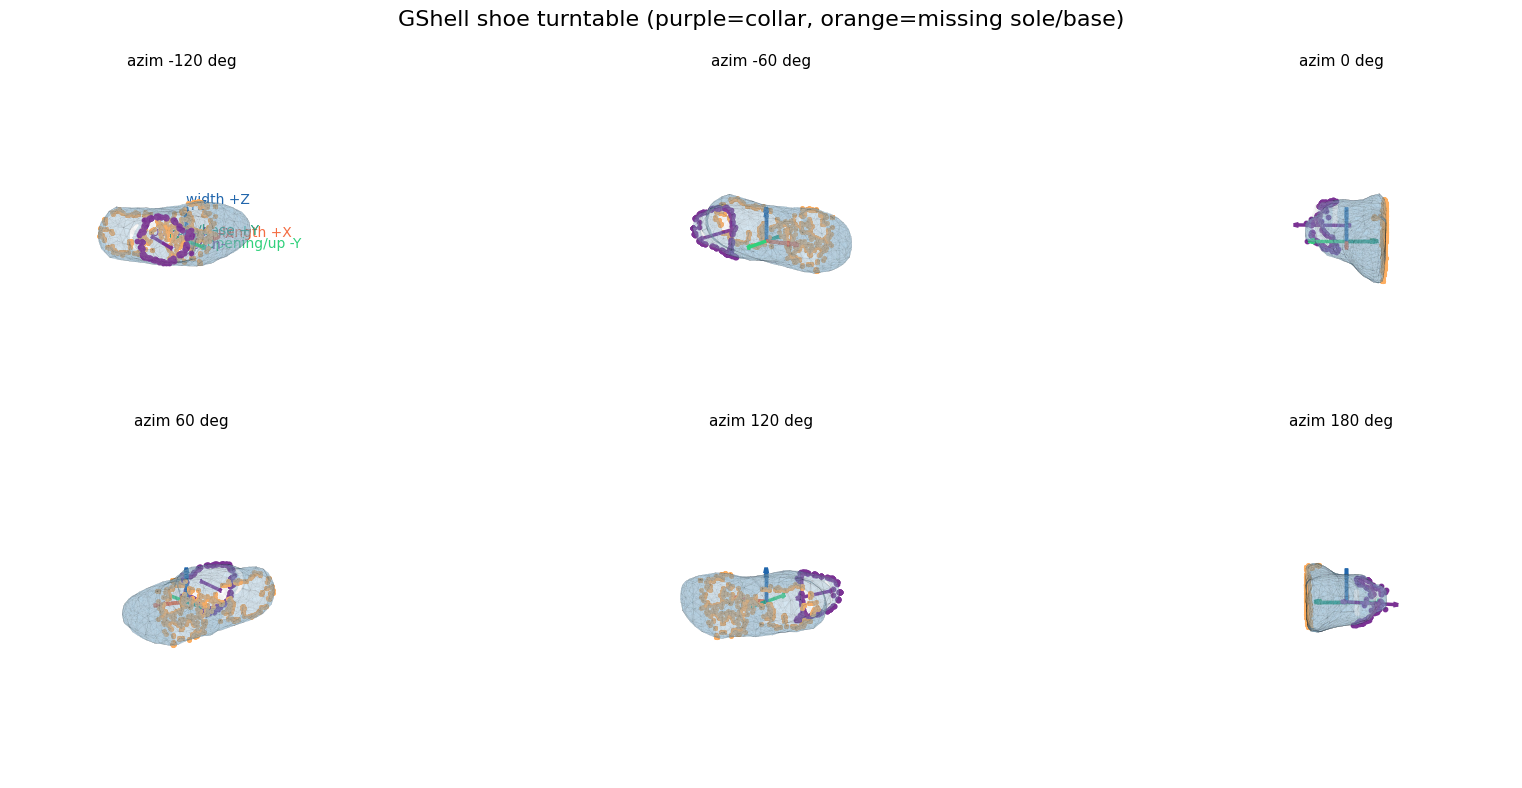

In [48]:
print_bounds("shell mesh", shell_mesh.vertices)
print_bounds("watertight mesh", watertight_mesh.vertices)

transforms_path = DATASET_SCENE / "transforms.json"
if transforms_path.exists():
    payload = json.loads(transforms_path.read_text())
    centers = []
    for frame in payload.get("frames", []):
        matrix = np.asarray(frame["transform_matrix"], dtype=np.float32)
        centers.append(matrix[:3, 3])
    centers = np.asarray(centers, dtype=np.float32)
    print("camera center min  :", centers.min(axis=0))
    print("camera center max  :", centers.max(axis=0))
    print("camera center range:", centers.ptp(axis=0))
    print("note: camera orbit is useful context, but it is not used to define anatomical up here")

opening = detect_shoe_opening_boundary(shell_mesh, shoe_axis_config)
if opening is None:
    print("No collar/opening boundary detected after filtering sole-like boundaries.")
    opening_vertices = None
    opening_normal = None
else:
    opening_vertices = shell_mesh.vertices[np.asarray(opening["vertices"], dtype=np.int64)]
    opening_normal = np.asarray(opening["normal"], dtype=np.float32)
    print("detected collar/opening component index:", opening["index"])
    print("detected opening center:", opening["center"])
    print("detected opening bounds min:", opening["bounds_min"])
    print("detected opening bounds max:", opening["bounds_max"])
    print("detected opening size:", opening["size"])
    print("detected opening fitted normal, sign ambiguous:", opening_normal)
    print("height_position:", opening["height_position"], "length_ratio:", opening["length_ratio"], "width_ratio:", opening["width_ratio"])

print()
print("Data-backed shoe facts:")
print("  shoe length axis is X")
print("  shoe height/opening-to-sole axis is Y")
print("  shoe width axis is Z")
print("  the large orange boundary is the missing sole/base and should not be used as the collar")
print("  the purple boundary is the collar candidate used for ankle-loop alignment")

shoe_origin = mesh_bounds(watertight_mesh.vertices)[3]


def draw_shoe_scene(ax, show_labels=True):
    add_mesh(ax, shell_mesh, color="#74add1", alpha=0.30, max_faces=3500, linewidth=0.035)
    add_mesh(ax, watertight_mesh, color="#bdbdbd", alpha=0.10, max_faces=2500, linewidth=0.025)
    add_world_axes(ax, shoe_origin, length=0.050, labels=show_labels)
    add_arrow(ax, shoe_origin, [1, 0, 0], "length +X" if show_labels else "", "#f46d43", length=0.065)
    add_arrow(ax, shoe_origin, [0, -1, 0], "opening/up -Y" if show_labels else "", "#31d17c", length=0.065)
    add_arrow(ax, shoe_origin, [0, 1, 0], "sole/base +Y" if show_labels else "", "#1b9e77", length=0.055)
    add_arrow(ax, shoe_origin, [0, 0, 1], "width +Z" if show_labels else "", "#2166ac", length=0.060)
    for item in sole_like_boundaries[:1]:
        vertices = shell_mesh.vertices[item["vertices"]]
        ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color="#fdae61", s=7, depthshade=False)
    if opening_vertices is not None:
        ax.scatter(opening_vertices[:, 0], opening_vertices[:, 1], opening_vertices[:, 2], color="#7b3294", s=10, depthshade=False)
        open_center = np.asarray(opening["center"], dtype=np.float32)
        add_arrow(ax, open_center, opening_normal, "open n+" if show_labels else "", "#7b3294", length=0.05)
        add_arrow(ax, open_center, -opening_normal, "open n-" if show_labels else "", "#7b3294", length=0.05)

plot_turntable(
    draw_shoe_scene,
    [shell_mesh.vertices, watertight_mesh.vertices],
    "GShell shoe turntable (purple=collar, orange=missing sole/base)",
    OUT_DIR / "02_shoe_axes_opening_turntable.png",
    elev=12,
)


## 8. Transformed SUPR Foot Inside Shoe

This shows what the transformation matrix actually does to the SUPR anatomy directions after remap, scale, yaw, and translation.

alignment scale: 0.8347484210259871
auto yaw degrees: -6.60911216210538
opening center: (-0.0739869773387909, -0.03770073503255844, 0.005967399105429649)
ankle center after transform: (-0.0739869773387909, -0.044388048350811005, 0.005967399571090937)

Transformed SUPR anatomy directions in shoe coordinates:
  toes direction       : [0.9933545  0.         0.11509513]
  ankle cut direction  : [ 0. -1.  0.]
  sole direction       : [0. 1. 0.]
  width direction      : [-0.11509513  0.          0.9933545 ]

Expected after remap/yaw:
  toe direction should be mostly along shoe +X
  ankle cut should be mostly along shoe -Y
  sole should be mostly along shoe +Y
  width should be mostly along shoe +Z


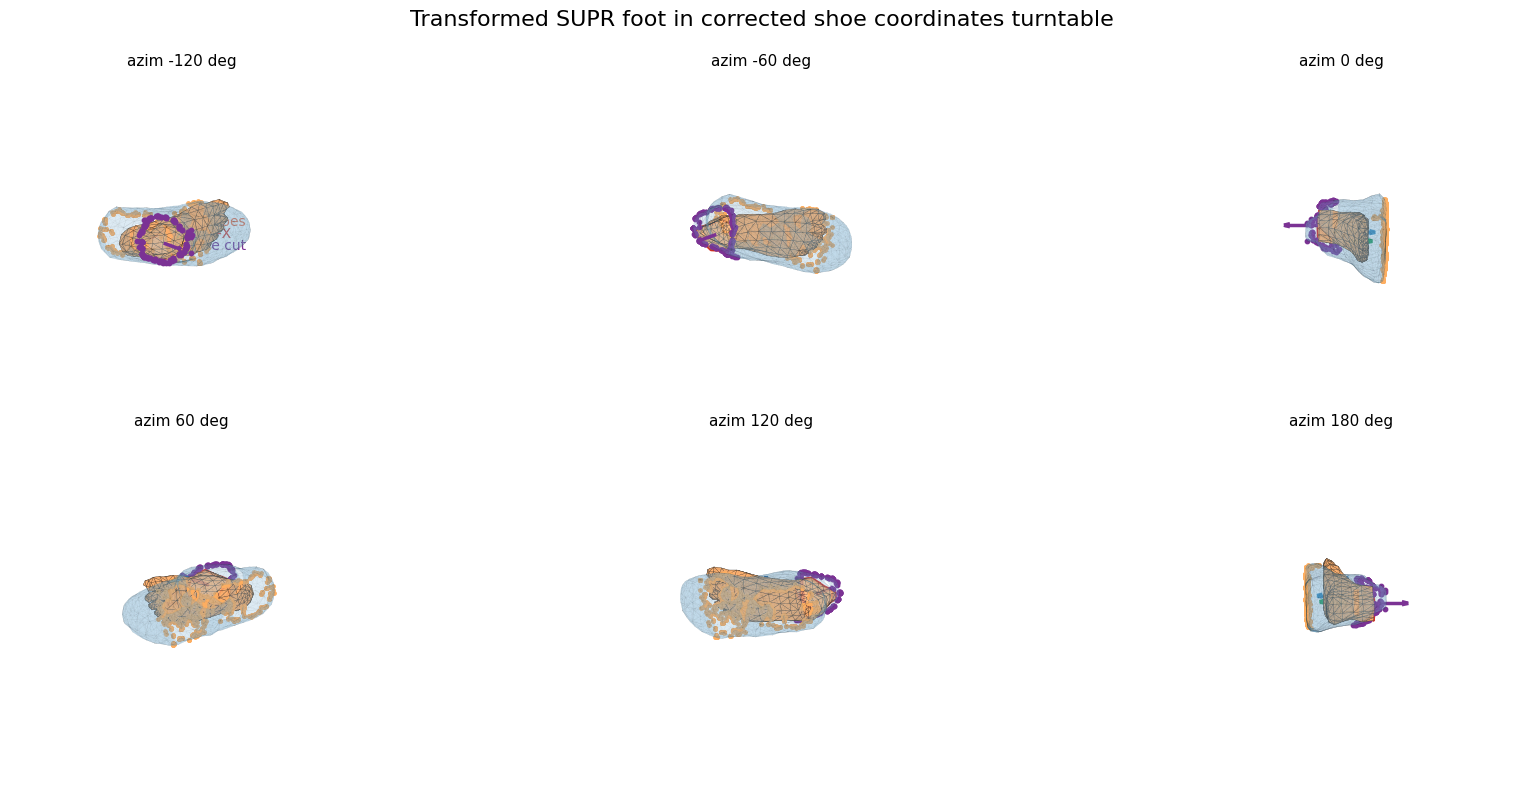

In [49]:
config = FootAlignmentConfig(
    length_ratio=0.78,
    plantar_clearance=0.032,
    shoe_length_axis=0,
    shoe_up_axis=1,
    shoe_width_axis=2,
    shoe_length_sign=1.0,
    shoe_up_sign=-1.0,
    shoe_width_sign=1.0,
    align_ankle_to_opening=True,
    auto_yaw=True,
)
alignment = build_alignment_from_meshes(
    foot_mesh=foot_mesh,
    shoe_mesh=watertight_mesh,
    opening_mesh=shell_mesh,
    config=config,
)
foot_aligned = MeshData(alignment.transform_foot_to_shoe(foot_mesh.vertices), foot_mesh.faces)
ankle_loop_aligned = alignment.transform_foot_to_shoe(foot_mesh.vertices[loop_indices])

# Direction vectors transform by the linear part of foot_to_shoe, without translation.
linear = alignment.foot_to_shoe[:3, :3]
transformed_toe = unit(linear @ np.asarray([0, 0, 1], dtype=np.float32))
transformed_ankle = unit(linear @ np.asarray([0, 1, 0], dtype=np.float32))
transformed_sole = unit(linear @ np.asarray([0, -1, 0], dtype=np.float32))
transformed_width = unit(linear @ np.asarray([1, 0, 0], dtype=np.float32))

print("alignment scale:", alignment.scale)
print("auto yaw degrees:", alignment.auto_yaw_degrees)
print("opening center:", alignment.opening_center)
print("ankle center after transform:", alignment.ankle_center_shoe)
print()
print("Transformed SUPR anatomy directions in shoe coordinates:")
print("  toes direction       :", transformed_toe)
print("  ankle cut direction  :", transformed_ankle)
print("  sole direction       :", transformed_sole)
print("  width direction      :", transformed_width)
print()
print("Expected after remap/yaw:")
print("  toe direction should be mostly along shoe +X")
print("  ankle cut should be mostly along shoe -Y")
print("  sole should be mostly along shoe +Y")
print("  width should be mostly along shoe +Z")

foot_origin = np.asarray(mesh_bounds(foot_aligned.vertices)[3], dtype=np.float32)
shoe_origin = mesh_bounds(watertight_mesh.vertices)[3]


def draw_transformed_scene(ax, show_labels=True):
    add_mesh(ax, shell_mesh, color="#74add1", alpha=0.25, max_faces=3500, linewidth=0.035)
    add_mesh(ax, foot_aligned, color="#fdae6b", alpha=0.82, max_faces=900, linewidth=0.18)
    ax.plot(
        np.r_[ankle_loop_aligned[:, 0], ankle_loop_aligned[0, 0]],
        np.r_[ankle_loop_aligned[:, 1], ankle_loop_aligned[0, 1]],
        np.r_[ankle_loop_aligned[:, 2], ankle_loop_aligned[0, 2]],
        color="#d73027",
        linewidth=2.0,
    )
    add_world_axes(ax, shoe_origin, length=0.045, labels=show_labels)
    add_arrow(ax, foot_origin, transformed_toe, "toes" if show_labels else "", "#f46d43", length=0.065)
    add_arrow(ax, foot_origin, transformed_sole, "sole" if show_labels else "", "#3288bd", length=0.055)
    add_arrow(ax, ankle_loop_aligned.mean(axis=0), transformed_ankle, "ankle cut" if show_labels else "", "#7b3294", length=0.060)
    if opening is not None:
        ax.scatter(opening_vertices[:, 0], opening_vertices[:, 1], opening_vertices[:, 2], color="#7b3294", s=10, depthshade=False)
    for item in sole_like_boundaries[:1]:
        vertices = shell_mesh.vertices[item["vertices"]]
        ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color="#fdae61", s=6, depthshade=False)

plot_turntable(
    draw_transformed_scene,
    [shell_mesh.vertices, foot_aligned.vertices],
    "Transformed SUPR foot in corrected shoe coordinates turntable",
    OUT_DIR / "03_transformed_foot_axes_in_shoe_turntable.png",
    elev=12,
)


## 9. What To Trust

Use this cell as the sanity checklist before changing alignment code.

In [50]:
print("Sanity checklist")
print("1. Raw SUPR foot: toes are +Z, ankle cut normal is +Y, sole is -Y.")
print("2. Raw GShell shoe: length is X, height/opening-to-sole is Y, width is Z.")
print("3. Sign for this mesh: +Y is the missing sole/base side, -Y is the opening/up side.")
print("4. Axis remap: SUPR +Z -> shoe +X, SUPR +Y -> shoe -Y, SUPR -Y -> shoe +Y, SUPR +X -> shoe +Z.")
print("5. The orange boundary is the missing sole/base; the purple boundary is the collar candidate.")
print("6. If the purple boundary does not match the real shoe collar, debug opening detection before changing the foot axes.")
print("debug images written to:", OUT_DIR)


Sanity checklist
1. Raw SUPR foot: toes are +Z, ankle cut normal is +Y, sole is -Y.
2. Raw GShell shoe: length is X, height/opening-to-sole is Y, width is Z.
3. Sign for this mesh: +Y is the missing sole/base side, -Y is the opening/up side.
4. Axis remap: SUPR +Z -> shoe +X, SUPR +Y -> shoe -Y, SUPR -Y -> shoe +Y, SUPR +X -> shoe +Z.
5. The orange boundary is the missing sole/base; the purple boundary is the collar candidate.
6. If the purple boundary does not match the real shoe collar, debug opening detection before changing the foot axes.
debug images written to: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/axis_debug/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids
